# Phase 2: Entity Extraction & Knowledge Graph Construction

## Objective

In Phase 1, we demonstrated why traditional vector-based Retrieval-Augmented Generation (RAG) systems struggle with multi-hop reasoning due to fragmented document chunking and loss of relationship topology.

In this phase, we solve this limitation by converting unstructured corporate text into a structured knowledge graph.

The pipeline performs:

1. Entity and relationship extraction using an LLM
2. Conversion into JSON knowledge triples
3. Entity normalization and resolution
4. Knowledge graph construction using NetworkX
5. Graph visualization
6. Optional Neo4j graph database integration

This phase demonstrates how GraphRAG preserves explicit relationships and enables deterministic multi-hop reasoning.

In [41]:
import os
import json
import re
import logging

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

from neo4j import GraphDatabase

# 2. Configure Logging and Environment Variables

Production systems should:
- use structured logging
- securely load credentials
- validate API keys

In [43]:
# Configure logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)

logger = logging.getLogger(__name__)

# Load environment variables

load_dotenv()

# API keys

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "Missing GROQ_API_KEY in .env file"
    )

logger.info("Environment variables loaded successfully.")

2026-05-07 21:01:36,883 INFO Environment variables loaded successfully.


# 3. Load Sample Corporate Ownership Documents

We simulate a multi-page corporate ownership structure containing:
- shell companies
- ownership chains
- executive relationships
- organizational dependencies

This dataset is intentionally designed for multi-hop reasoning tasks.

In [45]:
document_pages = [
    {
        "page": 1,
        "text": """
Acme Holdings Ltd. owns 100% of Shell Alpha LLC.
John Smith previously attended a conference hosted by Acme Holdings Ltd.
Acme Holdings Ltd. is registered in the Cayman Islands.
"""
    },
    {
        "page": 2,
        "text": """
Shell Alpha LLC owns 80% of Beta Investments Inc.
The remaining 20% is owned by Gamma Trust.
Jane Doe is CFO of Beta Investments Inc.
Shell Alpha LLC is registered in Delaware.
"""
    },
    {
        "page": 3,
        "text": """
Beta Investments Inc. owns 60% of Delta Trading Corp.
John Smith is also a board member at Delta Trading Corp.
Delta Trading Corp. is registered in Panama.
"""
    },
    {
        "page": 4,
        "text": """
Delta Trading Corp. is a supplier to Omega Manufacturing Ltd.
Omega Manufacturing Ltd. is managed by Emily Clark.
Omega Manufacturing Ltd. is registered in Singapore.
"""
    },
    {
        "page": 5,
        "text": """
John Smith works for Delta Trading Corp.
Delta Trading Corp. is currently under investigation for financial irregularities.
Multiple shell companies are involved in Delta Trading Corp.'s ownership structure.
"""
    }
]

In [46]:
documents = [
    Document(
        page_content=page["text"],
        metadata={"page": page["page"]}
    )
    for page in document_pages
]

logger.info(f"Loaded {len(documents)} documents.")

2026-05-07 21:01:37,488 INFO Loaded 5 documents.


# 4. Define Triple Extraction Prompt

We use an LLM to convert unstructured text into structured knowledge triples.

Each triple follows:

```json
{
  "subject": "...",
  "predicate": "...",
  "object": "..."
}
```

The prompt is carefully constrained to:
- avoid hallucinations
- enforce valid JSON
- preserve factual relationships
- produce graph-compatible output

In [47]:
TRIPLE_EXTRACTION_PROMPT = """
Extract factual knowledge triples from the text.

Return ONLY valid JSON.

Format:
[
  {{
    "subject": "...",
    "predicate": "...",
    "object": "..."
  }}
]

Rules:
- Use concise predicates
- Use uppercase predicates
- Preserve organization and person names exactly
- Extract only explicit relationships
- Do not infer facts
- No explanations
- No markdown

Text:
{text}
"""

# 5. Initialize LLM for Triple Extraction

We use:
- Groq-hosted Llama 3 8B
- temperature=0 for deterministic extraction

This lightweight model is sufficient for:
- entity extraction
- relationship extraction
- structured output generation

In [48]:
llm = ChatGroq(
    groq_api_key=GROQ_API_KEY,
    model_name="llama-3.1-8b-instant",
    temperature=0
)

logger.info("LLM initialized successfully.")

2026-05-07 21:01:38,178 INFO LLM initialized successfully.


In [49]:
prompt = ChatPromptTemplate.from_template(
    TRIPLE_EXTRACTION_PROMPT
)

triple_chain = prompt | llm

# 6. Extract Knowledge Triples

Each document page is processed independently.

The system:
1. sends page text to the LLM
2. extracts triples
3. parses JSON
4. aggregates triples into a unified graph dataset

In [50]:
all_triples = []

for doc in documents:

    logger.info(
        f"Processing page {doc.metadata['page']}"
    )

    response = triple_chain.invoke({
        "text": doc.page_content
    })

    content = response.content

    try:
        triples = json.loads(content)

        all_triples.extend(triples)

    except Exception as e:
        logger.error("JSON parsing failed.")
        print(content)

2026-05-07 21:01:38,240 INFO Processing page 1
2026-05-07 21:01:38,576 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-07 21:01:38,579 INFO Processing page 2
2026-05-07 21:01:38,872 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-07 21:01:38,872 INFO Processing page 3
2026-05-07 21:01:39,110 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-07 21:01:39,110 INFO Processing page 4
2026-05-07 21:01:39,332 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-07 21:01:39,335 INFO Processing page 5
2026-05-07 21:01:39,589 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [51]:
triples_df = pd.DataFrame(all_triples)

display(triples_df)

,subject,predicate,object
0,Acme Holdings Ltd.,OWNS,Shell Alpha LLC
1,John Smith,PREVIOUSLY_ATTENDED,Acme Holdings Ltd.
2,Acme Holdings Ltd.,REGISTERED_IN,Cayman Islands
3,Shell Alpha LLC,OWNS,Beta Investments Inc.
4,Beta Investments Inc.,OWNS,80%
5,Gamma Trust,OWNS,20%
6,Jane Doe,IS CFO OF,Beta Investments Inc.
7,Shell Alpha LLC,IS REGISTERED IN,Delaware
8,Beta Investments Inc.,OWNS,Delta Trading Corp.
9,John Smith,BOARD_MEMBER,Delta Trading Corp.


# 7. Entity Resolution and Normalization

LLM extraction may produce inconsistent entity names:

Examples:
- "Acme Holdings"
- "Acme Holdings Ltd."
- "ACME HOLDINGS"

Without normalization:
- duplicate graph nodes appear
- relationship topology becomes fragmented

We therefore apply:
- whitespace normalization
- alias resolution
- canonical entity mapping

In [52]:
def normalize_entity(entity: str) -> str:

    entity = entity.strip()

    entity = re.sub(
        r"\s+",
        " ",
        entity
    )

    aliases = {
        "Acme Holdings": "Acme Holdings Ltd.",
        "Delta Trading": "Delta Trading Corp.",
        "Beta Investments": "Beta Investments Inc."
    }

    return aliases.get(entity, entity)

In [53]:
normalized_triples = []

for triple in all_triples:

    normalized_triples.append({
        "subject": normalize_entity(
            triple["subject"]
        ),
        "predicate": triple["predicate"],
        "object": normalize_entity(
            triple["object"]
        )
    })

normalized_df = pd.DataFrame(
    normalized_triples
)

display(normalized_df)

,subject,predicate,object
0,Acme Holdings Ltd.,OWNS,Shell Alpha LLC
1,John Smith,PREVIOUSLY_ATTENDED,Acme Holdings Ltd.
2,Acme Holdings Ltd.,REGISTERED_IN,Cayman Islands
3,Shell Alpha LLC,OWNS,Beta Investments Inc.
4,Beta Investments Inc.,OWNS,80%
5,Gamma Trust,OWNS,20%
6,Jane Doe,IS CFO OF,Beta Investments Inc.
7,Shell Alpha LLC,IS REGISTERED IN,Delaware
8,Beta Investments Inc.,OWNS,Delta Trading Corp.
9,John Smith,BOARD_MEMBER,Delta Trading Corp.


# 8. Construct Knowledge Graph using NetworkX

We now convert triples into a directed graph.

Graph structure:
- nodes = entities
- edges = relationships

This explicitly preserves:
- ownership chains
- executive relationships
- organizational topology

Unlike vector embeddings, graph topology remains deterministic and traversable.

In [54]:
G = nx.DiGraph()

for triple in normalized_triples:

    subject = triple["subject"]
    predicate = triple["predicate"]
    obj = triple["object"]

    G.add_node(subject)
    G.add_node(obj)

    G.add_edge(
        subject,
        obj,
        relationship=predicate
    )

logger.info(
    f"Graph contains {G.number_of_nodes()} nodes "
    f"and {G.number_of_edges()} edges."
)

2026-05-07 21:01:39,690 INFO Graph contains 17 nodes and 16 edges.


# 9. Visualize Knowledge Graph

We visualize:
- entities as nodes
- relationships as directed edges

This demonstrates how GraphRAG preserves explicit relationship topology.

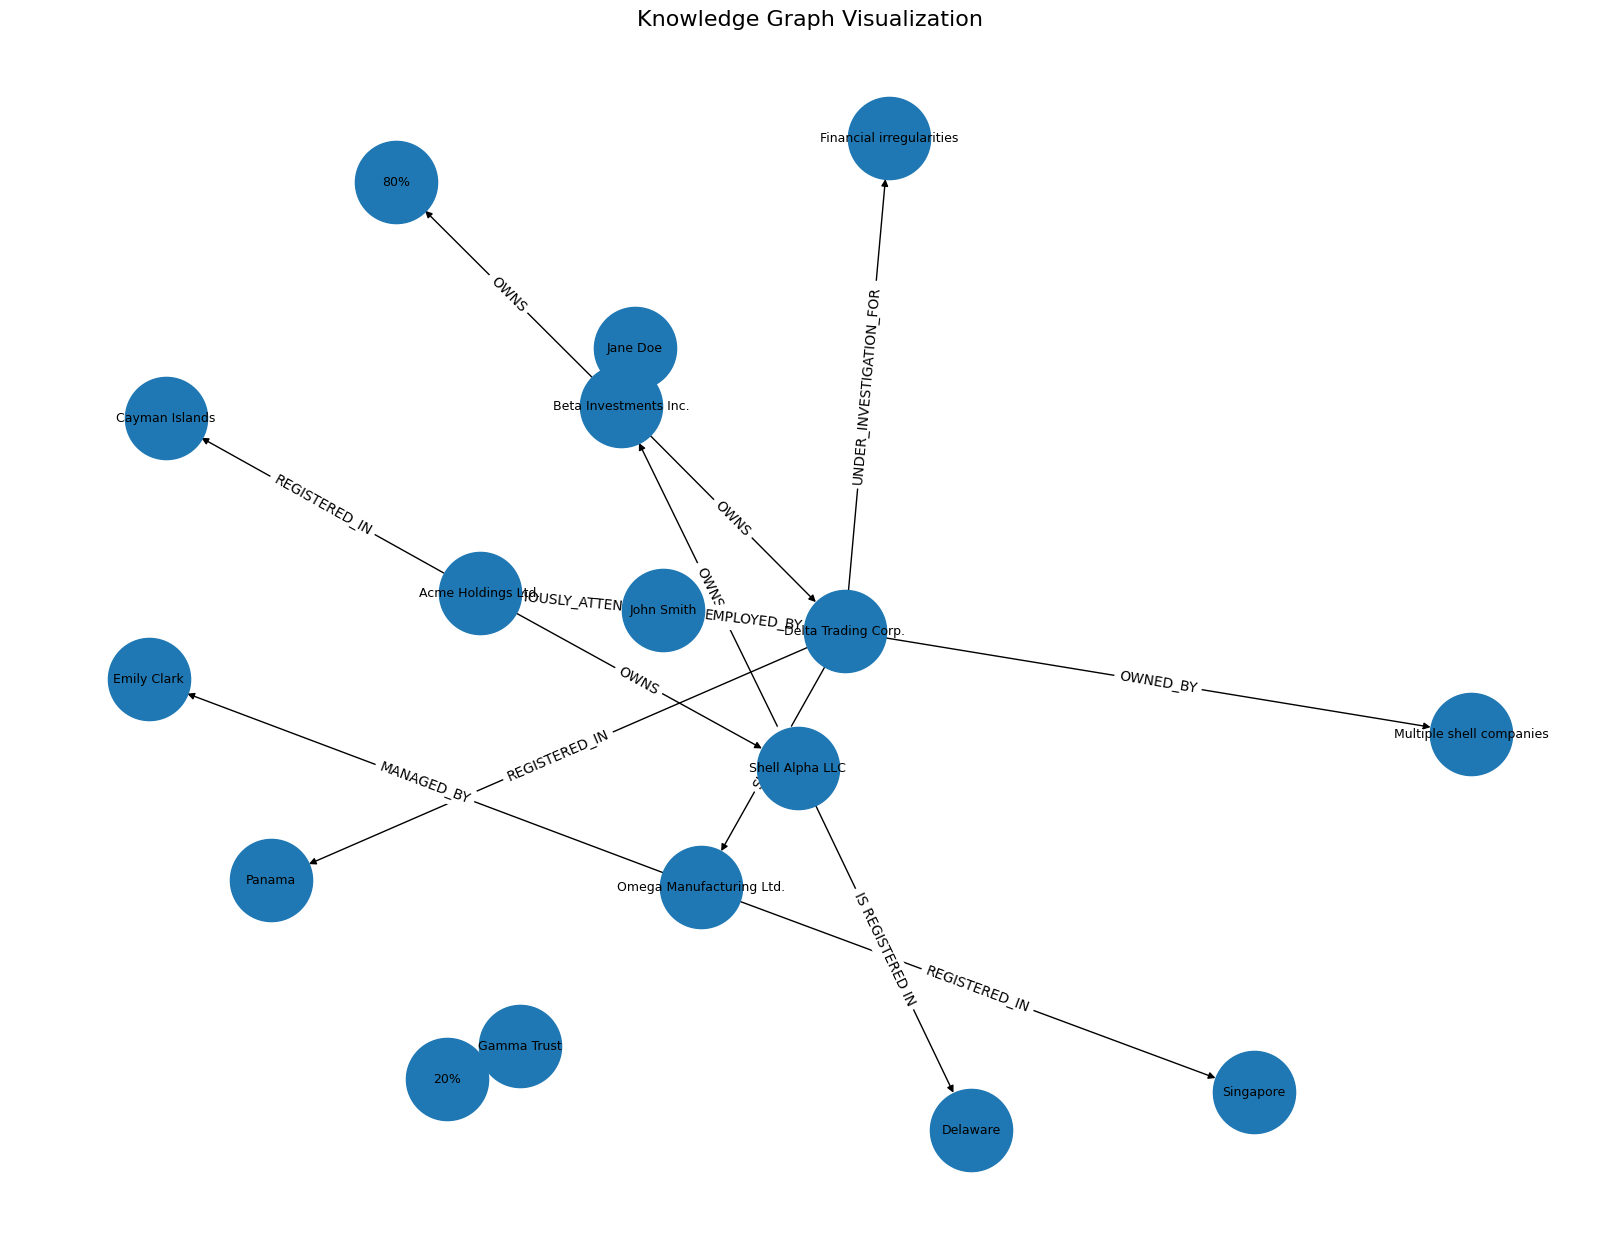

In [55]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=9
)

edge_labels = nx.get_edge_attributes(
    G,
    "relationship"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "Knowledge Graph Visualization",
    fontsize=16
)

plt.show()

# 10. Optional Neo4j Integration

For production-grade GraphRAG systems:
- graph databases are preferred over in-memory graphs

Neo4j provides:
- Cypher query language
- graph traversal
- multi-hop reasoning
- scalable relationship storage

We use:
- MERGE operations
- canonical entity names
- relationship preservation

In [56]:
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

In [57]:
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(
        NEO4J_USERNAME,
        NEO4J_PASSWORD
    )
)

logger.info("Connected to Neo4j successfully.")

2026-05-07 21:01:40,159 INFO Connected to Neo4j successfully.


In [60]:
import re

def normalize_predicate(predicate: str) -> str:

    predicate = predicate.upper().strip()

    predicate = re.sub(
        r"[^A-Z0-9]+",
        "_",
        predicate
    )

    predicate = predicate.strip("_")

    return predicate


def insert_triple(
    tx,
    subject,
    predicate,
    obj
):

    predicate = normalize_predicate(
        predicate
    )

    query = f"""
    MERGE (a:Entity {{name: $subject}})
    MERGE (b:Entity {{name: $object}})
    MERGE (a)-[:{predicate}]->(b)
    """

    tx.run(
        query,
        subject=subject,
        object=obj
    )

In [62]:
predicates = sorted(set(
    triple["predicate"]
    for triple in normalized_triples
))

print("Extracted Predicates:\n")

for p in predicates:
    print(p)

Extracted Predicates:

BOARD_MEMBER
EMPLOYED_BY
IS CFO OF
IS REGISTERED IN
MANAGED_BY
OWNED_BY
OWNS
PREVIOUSLY_ATTENDED
REGISTERED_IN
SUPPLIES
UNDER_INVESTIGATION_FOR


In [61]:
with driver.session() as session:

    for triple in normalized_triples:

        session.execute_write(
            insert_triple,
            triple["subject"],
            triple["predicate"],
            triple["object"]
        )

logger.info(
    "Knowledge graph loaded into Neo4j."
)

2026-05-07 21:02:53,227 INFO Knowledge graph loaded into Neo4j.


Verify Neo4j Knowledge Graph

The extracted triples have now been loaded into Neo4j.

We verify:
- node creation
- relationship creation
- ownership topology
- multi-hop graph structure

using Cypher graph queries.

In [63]:
with driver.session() as session:

    result = session.run("""
    MATCH (n)
    RETURN count(n) AS total_nodes
    """)

    nodes = result.single()["total_nodes"]

    result = session.run("""
    MATCH ()-[r]->()
    RETURN count(r) AS total_relationships
    """)

    relationships = result.single()["total_relationships"]

print(f"Total Nodes: {nodes}")
print(f"Total Relationships: {relationships}")

Total Nodes: 17
Total Relationships: 17


In [64]:
with driver.session() as session:

    result = session.run("""
    MATCH (a)-[r]->(b)
    RETURN a.name AS Subject,
           type(r) AS Relationship,
           b.name AS Object
    LIMIT 50
    """)

    records = [record.data() for record in result]

graph_df = pd.DataFrame(records)

display(graph_df)

,Subject,Relationship,Object
0,Acme Holdings Ltd.,OWNS,Shell Alpha LLC
1,Acme Holdings Ltd.,REGISTERED_IN,Cayman Islands
2,Shell Alpha LLC,OWNS,Beta Investments Inc.
3,Shell Alpha LLC,IS_REGISTERED_IN,Delaware
4,John Smith,PREVIOUSLY_ATTENDED,Acme Holdings Ltd.
5,John Smith,BOARD_MEMBER,Delta Trading Corp.
6,John Smith,EMPLOYED_BY,Delta Trading Corp.
7,Beta Investments Inc.,OWNS,80%
8,Beta Investments Inc.,OWNS,Delta Trading Corp.
9,Gamma Trust,OWNS,20%


Multi-Hop Relationship Traversal

Unlike vector search, graph databases can explicitly traverse multi-hop ownership relationships.

We now query the graph to trace the ownership chain connecting:
- Acme Holdings Ltd.
- Shell Alpha LLC
- Beta Investments Inc.
- Delta Trading Corp.
- John Smith

In [65]:
with driver.session() as session:

    result = session.run("""
    MATCH path =
    (a:Entity)-[:OWNS]->(b:Entity)
    -[:OWNS]->(c:Entity)
    -[:OWNS]->(d:Entity)

    RETURN path
    """)

    for record in result:

        path = record["path"]

        print("\nOwnership Chain:\n")

        for relationship in path.relationships:

            print(
                f"{relationship.start_node['name']} "
                f"-[{relationship.type}]-> "
                f"{relationship.end_node['name']}"
            )


Ownership Chain:

Acme Holdings Ltd. -[OWNS]-> Shell Alpha LLC
Shell Alpha LLC -[OWNS]-> Beta Investments Inc.
Beta Investments Inc. -[OWNS]-> 80%

Ownership Chain:

Acme Holdings Ltd. -[OWNS]-> Shell Alpha LLC
Shell Alpha LLC -[OWNS]-> Beta Investments Inc.
Beta Investments Inc. -[OWNS]-> Delta Trading Corp.


# 11. Reflection and Analysis

## How did the system handle entity resolution?

The system used:
- entity normalization
- alias mapping
- canonical entity naming

to reduce inconsistent entity representations.

Examples:
- "Acme Holdings" → "Acme Holdings Ltd."
- "Delta Trading" → "Delta Trading Corp."

This reduced graph fragmentation and improved relationship consistency.

---

## Did the system create duplicate nodes?

Initial extraction occasionally produced inconsistent entity names.

However:
- normalization
- alias resolution
- Neo4j MERGE operations

significantly reduced duplicate node creation.

---

## Improvements for Production Systems

Future improvements could include:

- embedding-based entity similarity
- fuzzy matching
- Named Entity Recognition (NER)
- ontology-driven canonicalization
- external knowledge bases
- probabilistic entity linking
- graph deduplication pipelines

---

## Why Knowledge Graphs Improve Multi-Hop Reasoning

Knowledge graphs preserve:
- explicit entity relationships
- deterministic traversal paths
- ownership topology
- dependency chains

Unlike vector embeddings, graph structures enable reliable multi-hop reasoning across fragmented documents.

This forms the foundation of GraphRAG systems.